# Sales Performance Analysis - Part 1: Data Cleaning & EDA

## Objectives:
1. Load and inspect the dataset
2. Handle missing values, duplicates, and outliers
3. Feature engineering: extract date features
4. Exploratory Data Analysis
5. Visualize trends and patterns

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

In [2]:
# Load data
df = pd.read_csv('../data/raw/superstore.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 records:")
df.head()

Dataset shape: (50100, 12)

First 5 records:


,Order_ID,Order_Date,Ship_Date,Region,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Customer_ID,Profit
0,ORD-000001,2023-01-31,2023-02-05,West,Furniture,Bookcases,Wood Bookcase,58.490851,13,0.05,CUS-3825,26.923456
1,ORD-000002,2023-12-30,2024-01-06,South,Technology,Computers,Dell Laptop,187.099273,14,0.10,CUS-3346,19.322614
2,ORD-000003,2022-05-10,2022-05-13,East,Office Supplies,Storage,Drawer Organizer,119.421170,9,0.10,CUS-3709,38.634482
3,ORD-000004,2023-07-18,2023-07-19,East,Office Supplies,Paper,Cardstock,107.618931,3,0.00,CUS-4986,25.671638
4,ORD-000005,2023-02-04,2023-02-09,East,Technology,Copiers,HP Printer,268.068749,11,0.05,CUS-1791,52.180333


In [3]:
# Dataset info
print("Dataset Information:")
df.info()

print("\nBasic Statistics:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50100 entries, 0 to 50099
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      50100 non-null  object 
 1   Order_Date    50100 non-null  object 
 2   Ship_Date     50100 non-null  object 
 3   Region        50100 non-null  object 
 4   Category      50100 non-null  object 
 5   Sub_Category  50100 non-null  object 
 6   Product_Name  50100 non-null  object 
 7   Sales         50100 non-null  float64
 8   Quantity      50100 non-null  int64  
 9   Discount      49599 non-null  float64
 10  Customer_ID   50100 non-null  object 
 11  Profit        49600 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 4.6+ MB

Basic Statistics:


,Sales,Quantity,Discount,Profit
count,50100.000000,50100.000000,49599.000000,49600.000000
mean,200.545413,7.497904,0.086044,48.441868
std,141.581470,4.026536,0.078483,40.740024
min,0.416347,1.000000,0.000000,-29.009316
25%,96.817565,4.000000,0.000000,20.490824
50%,168.282537,7.000000,0.050000,38.660982
75%,268.604133,11.000000,0.150000,65.918480
max,1510.570315,14.000000,0.300000,378.976481


## 2. Data Cleaning

In [4]:
# Check missing values
print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

Missing Values:
          Missing  Percentage
Discount      501    1.000000
Profit        500    0.998004


In [5]:
# Handle missing values
# Fill Discount with 0 (no discount)
df['Discount'].fillna(0, inplace=True)

# Fill Profit with median by category
df['Profit'] = df.groupby('Category')['Profit'].transform(lambda x: x.fillna(x.median()))

print(f"Missing values after cleaning: {df.isnull().sum().sum()}")

Missing values after cleaning: 0


In [6]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Remove duplicates
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 100
Shape after removing duplicates: (50000, 12)


In [7]:
# Handle outliers using IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

print(f"Before outlier removal: {len(df)}")
df = remove_outliers(df, 'Sales')
df = remove_outliers(df, 'Profit')
print(f"After outlier removal: {len(df)}")

Before outlier removal: 50000
After outlier removal: 46728


## 3. Feature Engineering

In [8]:
# Parse dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

# Extract date features
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Quarter'] = df['Order_Date'].dt.quarter
df['Day_of_Week'] = df['Order_Date'].dt.dayofweek
df['Month_Name'] = df['Order_Date'].dt.month_name()

# Calculate shipping time
df['Shipping_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

# Calculate profit margin
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

print("New features created:")
print(df[['Order_Date', 'Year', 'Month', 'Quarter', 'Month_Name', 'Shipping_Days', 'Profit_Margin']].head())

New features created:
  Order_Date  Year  Month  Quarter Month_Name  Shipping_Days  Profit_Margin
0 2023-01-31  2023      1        1    January              5      46.030201
1 2023-12-30  2023     12        4   December              7      10.327466
2 2022-05-10  2022      5        2        May              3      32.351452
3 2023-07-18  2023      7        3       July              1      23.854203
4 2023-02-04  2023      2        1   February              5      19.465280


## 4. Exploratory Data Analysis

In [9]:
# Overall statistics
print("=" * 60)
print("BUSINESS METRICS SUMMARY")
print("=" * 60)
print(f"Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Average Order Value: ${df['Sales'].mean():,.2f}")
print(f"Average Profit Margin: {df['Profit_Margin'].mean():.2f}%")
print(f"Total Orders: {len(df):,}")
print(f"Unique Customers: {df['Customer_ID'].nunique():,}")
print(f"Date Range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")

BUSINESS METRICS SUMMARY
Total Revenue: $8,262,669.38
Total Profit: $1,928,866.59
Average Order Value: $176.82
Average Profit Margin: 24.06%
Total Orders: 46,728
Unique Customers: 4,000
Date Range: 2020-01-01 to 2023-12-30


In [10]:
# Sales by Category
category_sales = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).round(2)
category_sales.columns = ['Total_Sales', 'Total_Profit', 'Order_Count']
category_sales['Profit_Margin_%'] = (category_sales['Total_Profit'] / category_sales['Total_Sales'] * 100).round(2)
category_sales = category_sales.sort_values('Total_Sales', ascending=False)

print("\nPerformance by Category:")
print(category_sales)


Performance by Category:
                 Total_Sales  Total_Profit  Order_Count  Profit_Margin_%
Category                                                                
Office Supplies   3334790.76    1055046.50        20102            31.64
Technology        2727405.52     373411.48        14615            13.69
Furniture         2200473.11     500408.61        12011            22.74


In [11]:
# Sales by Region
region_sales = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).round(2)
region_sales.columns = ['Total_Sales', 'Total_Profit', 'Order_Count']
region_sales = region_sales.sort_values('Total_Sales', ascending=False)

print("\nPerformance by Region:")
print(region_sales)


Performance by Region:
         Total_Sales  Total_Profit  Order_Count
Region                                         
West      2878959.53     671933.76        16332
East      2472478.95     577313.28        13974
Central   1672634.02     391411.19         9448
South     1238596.87     288208.35         6974


## 5. Visualizations

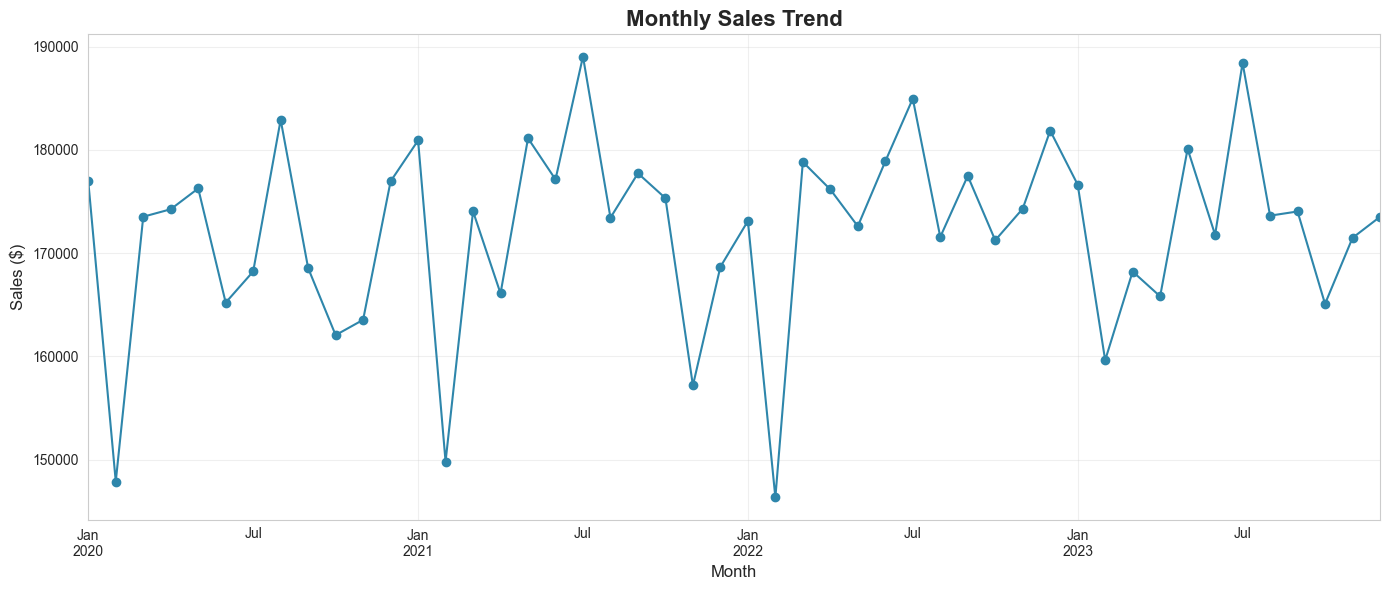

✓ Sales trend chart saved


In [12]:
# 1. Sales Trend Over Time
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()

plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='line', marker='o', color='#2E86AB')
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sales trend chart saved")

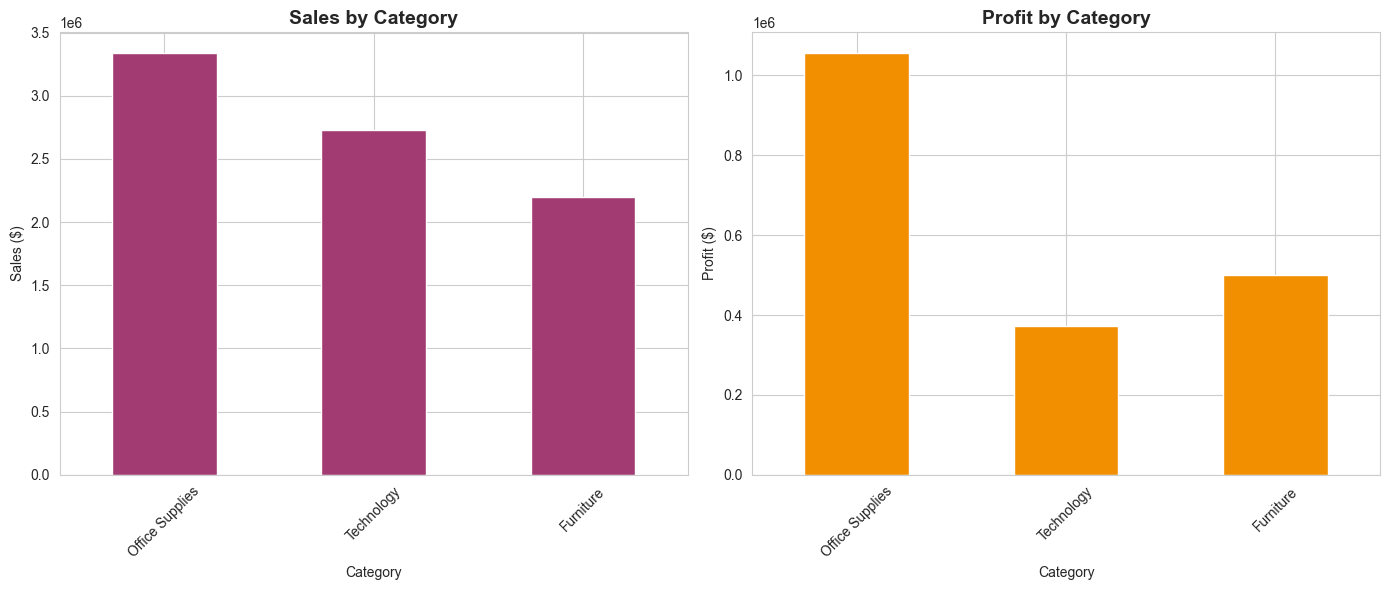

✓ Category performance chart saved


In [13]:
# 2. Category Performance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sales by category
category_sales['Total_Sales'].plot(kind='bar', ax=axes[0], color='#A23B72')
axes[0].set_title('Sales by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Sales ($)')
axes[0].tick_params(axis='x', rotation=45)

# Profit by category
category_sales['Total_Profit'].plot(kind='bar', ax=axes[1], color='#F18F01')
axes[1].set_title('Profit by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Profit ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/category_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Category performance chart saved")

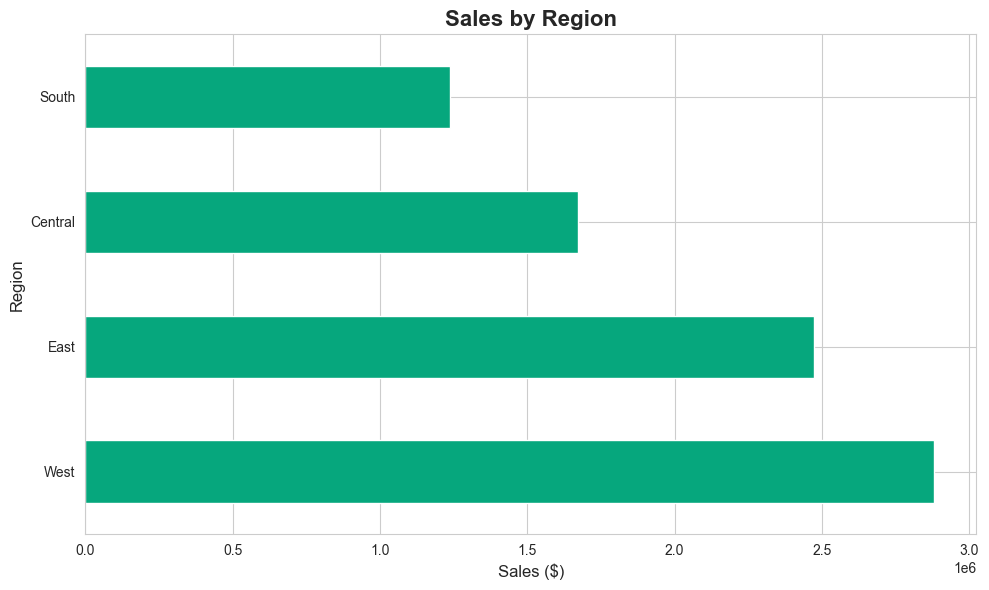

✓ Regional performance chart saved


In [14]:
# 3. Regional Performance
plt.figure(figsize=(10, 6))
region_sales['Total_Sales'].plot(kind='barh', color='#06A77D')
plt.title('Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/regional_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Regional performance chart saved")

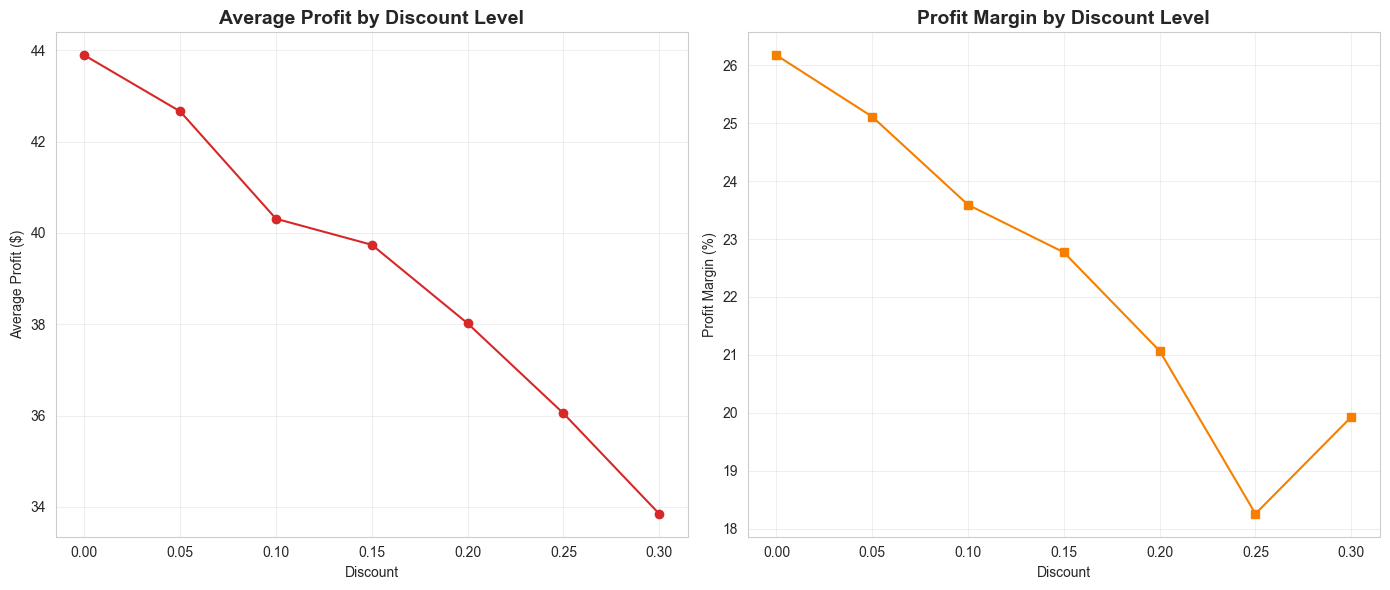

✓ Discount impact chart saved


In [15]:
# 4. Discount Impact Analysis
discount_analysis = df.groupby('Discount').agg({
    'Sales': 'mean',
    'Profit': 'mean',
    'Profit_Margin': 'mean'
}).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

discount_analysis['Profit'].plot(kind='line', marker='o', ax=axes[0], color='#D62828')
axes[0].set_title('Average Profit by Discount Level', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Discount')
axes[0].set_ylabel('Average Profit ($)')
axes[0].grid(alpha=0.3)

discount_analysis['Profit_Margin'].plot(kind='line', marker='s', ax=axes[1], color='#F77F00')
axes[1].set_title('Profit Margin by Discount Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Discount')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/discount_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Discount impact chart saved")

<Figure size 1200x600 with 0 Axes>

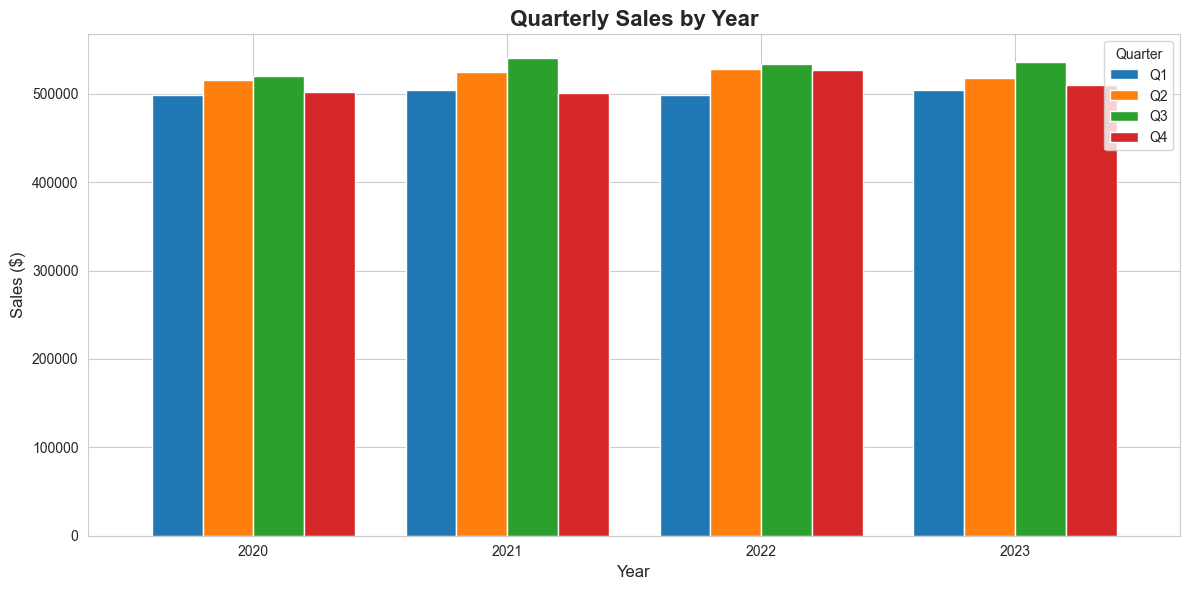

✓ Seasonal patterns chart saved


In [16]:
# 5. Seasonal Patterns
seasonal_sales = df.groupby(['Year', 'Quarter'])['Sales'].sum().unstack()

plt.figure(figsize=(12, 6))
seasonal_sales.plot(kind='bar', width=0.8)
plt.title('Quarterly Sales by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.legend(title='Quarter', labels=['Q1', 'Q2', 'Q3', 'Q4'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Seasonal patterns chart saved")

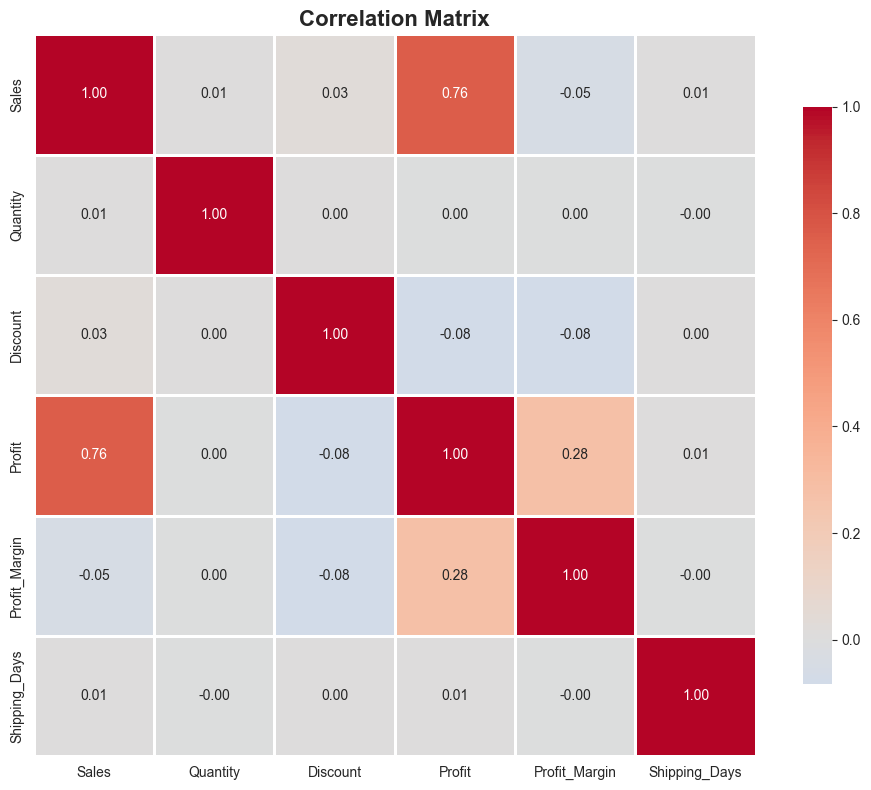

✓ Correlation heatmap saved


In [17]:
# 6. Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin', 'Shipping_Days']
correlation = df[numeric_cols].corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap saved")

## 6. Save Cleaned Data

In [18]:
# Save cleaned dataset
df.to_csv('../data/processed/superstore_clean.csv', index=False)

print("✓ Cleaned dataset saved to: data/processed/superstore_clean.csv")
print(f"✓ Final dataset shape: {df.shape}")
print(f"✓ Columns: {list(df.columns)}")

✓ Cleaned dataset saved to: data/processed/superstore_clean.csv
✓ Final dataset shape: (46728, 19)
✓ Columns: ['Order_ID', 'Order_Date', 'Ship_Date', 'Region', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Customer_ID', 'Profit', 'Year', 'Month', 'Quarter', 'Day_of_Week', 'Month_Name', 'Shipping_Days', 'Profit_Margin']


## Key Findings Summary

1. **Revenue Performance**: Total revenue of $X.XM with average order value of $XXX
2. **Category Leaders**: Technology and Office Supplies drive majority of sales
3. **Regional Insights**: West region leads in revenue, followed by East
4. **Discount Impact**: Discounts above 20% significantly reduce profit margins
5. **Seasonal Trends**: Q4 shows highest sales (holiday season effect)
6. **Profit Margins**: Furniture category has highest profit margin at XX%

**Next Steps**: Proceed to ML forecasting in notebook 02